# Amazon Kablosuz Kulaklık Ürünlerinde Açıklanabilir Ürün Analitiği

## Proje Amacı

Bu projede Amazon’da satılan kablosuz kulaklık ürünlerine ait kullanıcı yorumları ve ürün fiyat bilgileri birleştirilerek müşteri memnuniyetini etkileyen temel faktörler analiz edilmiştir.

Çalışmanın temel amacı, kullanıcı yorumlarından ürün problem alanlarını çıkarmak, makine öğrenmesi modeli ile müşteri memnuniyetini tahmin etmek, SHAP yöntemi ile model kararlarını açıklamak ve ürün geliştirme yatırımları için finansal fayda simülasyonu oluşturmaktır.

Bu kapsamda proje, ürün yöneticilerinin “hangi ürün problemini önce çözmeliyiz?” sorusuna veri temelli bir karar desteği sunmayı hedeflemektedir.


## 1. Kütüphanelerin Yüklenmesi

In [6]:
import shap
import numpy as np

## 2. Veri Setlerinin Yüklenmesi

In [7]:
import pandas as pd

# Verileri oku
reviews = pd.read_csv("AllProductReviews.csv")
products = pd.read_csv("ProductInfo.csv")

# Boyutları göster
print("Reviews shape:", reviews.shape)
print("Products shape:", products.shape)

Reviews shape: (14337, 4)
Products shape: (10, 6)


## 3. Veri Setlerinin İncelenmesi

In [8]:
reviews.head()

,ReviewTitle,ReviewBody,ReviewStar,Product
0,Honest review of an edm music lover\n,No doubt it has a great bass and to a great ex...,3,boAt Rockerz 255
1,Unreliable earphones with high cost\n,"This earphones are unreliable, i bought it be...",1,boAt Rockerz 255
2,Really good and durable.\n,"i bought itfor 999,I purchased it second time,...",4,boAt Rockerz 255
3,stopped working in just 14 days\n,Its sound quality is adorable. overall it was ...,1,boAt Rockerz 255
4,Just Awesome Wireless Headphone under 1000...😉\n,Its Awesome... Good sound quality & 8-9 hrs ba...,5,boAt Rockerz 255


In [9]:
products.head()

,MRP,Price,ProductFullName,ProductShortName,ReviewURL,id
0,2990,1399,boAt Rockerz 255 Sports Bluetooth Wireless Ear...,boAt Rockerz 255,https://www.amazon.in/255-Bluetooth-Wireless-E...,1
1,3999,1099,Flybot Wave in-Ear Sport Wireless Bluetooth Ea...,Flybot Wave,https://www.amazon.in/Flybot-Wireless-Bluetoot...,2
2,3999,1099,Flybot Boom Deep Bass in-Ear Wireless Bluetoot...,Flybot Boom,https://www.amazon.in/Flybot-Wireless-Bluetoot...,3
3,2000,749,PTron Intunes Pro Headphone Magnetic Earphone ...,PTron Intunes,https://www.amazon.in/PTron-Intunes-Pro-Smartp...,4
4,5999,2999,Flybot Beat True Wireless Bluetooth Earphones ...,Flybot Beat,https://www.amazon.in/Flybot-Wireless-Bluetoot...,5


## 4. Veri Harmanlama (Data Fusion)

Bu aşamada kullanıcı yorumları verisi ile ürün bilgileri verisi ürün adı üzerinden birleştirilmiştir. Böylece yorum metni, yıldız puanı, ürün fiyatı ve indirim bilgisi aynı analiz tablosunda toplanmıştır.

In [10]:
# İki veri setini ürün adına göre birleştirme
df = reviews.merge(
    products,
    left_on="Product",
    right_on="ProductShortName",
    how="left"
)

print("Merged dataset shape:", df.shape)
df.head()

Merged dataset shape: (14337, 10)


,ReviewTitle,ReviewBody,ReviewStar,Product,MRP,Price,ProductFullName,ProductShortName,ReviewURL,id
0,Honest review of an edm music lover\n,No doubt it has a great bass and to a great ex...,3,boAt Rockerz 255,2990,1399,boAt Rockerz 255 Sports Bluetooth Wireless Ear...,boAt Rockerz 255,https://www.amazon.in/255-Bluetooth-Wireless-E...,1
1,Unreliable earphones with high cost\n,"This earphones are unreliable, i bought it be...",1,boAt Rockerz 255,2990,1399,boAt Rockerz 255 Sports Bluetooth Wireless Ear...,boAt Rockerz 255,https://www.amazon.in/255-Bluetooth-Wireless-E...,1
2,Really good and durable.\n,"i bought itfor 999,I purchased it second time,...",4,boAt Rockerz 255,2990,1399,boAt Rockerz 255 Sports Bluetooth Wireless Ear...,boAt Rockerz 255,https://www.amazon.in/255-Bluetooth-Wireless-E...,1
3,stopped working in just 14 days\n,Its sound quality is adorable. overall it was ...,1,boAt Rockerz 255,2990,1399,boAt Rockerz 255 Sports Bluetooth Wireless Ear...,boAt Rockerz 255,https://www.amazon.in/255-Bluetooth-Wireless-E...,1
4,Just Awesome Wireless Headphone under 1000...😉\n,Its Awesome... Good sound quality & 8-9 hrs ba...,5,boAt Rockerz 255,2990,1399,boAt Rockerz 255 Sports Bluetooth Wireless Ear...,boAt Rockerz 255,https://www.amazon.in/255-Bluetooth-Wireless-E...,1


In [11]:
# Birleştirilmiş veri setinin ilk satırları
df.head()

,ReviewTitle,ReviewBody,ReviewStar,Product,MRP,Price,ProductFullName,ProductShortName,ReviewURL,id
0,Honest review of an edm music lover\n,No doubt it has a great bass and to a great ex...,3,boAt Rockerz 255,2990,1399,boAt Rockerz 255 Sports Bluetooth Wireless Ear...,boAt Rockerz 255,https://www.amazon.in/255-Bluetooth-Wireless-E...,1
1,Unreliable earphones with high cost\n,"This earphones are unreliable, i bought it be...",1,boAt Rockerz 255,2990,1399,boAt Rockerz 255 Sports Bluetooth Wireless Ear...,boAt Rockerz 255,https://www.amazon.in/255-Bluetooth-Wireless-E...,1
2,Really good and durable.\n,"i bought itfor 999,I purchased it second time,...",4,boAt Rockerz 255,2990,1399,boAt Rockerz 255 Sports Bluetooth Wireless Ear...,boAt Rockerz 255,https://www.amazon.in/255-Bluetooth-Wireless-E...,1
3,stopped working in just 14 days\n,Its sound quality is adorable. overall it was ...,1,boAt Rockerz 255,2990,1399,boAt Rockerz 255 Sports Bluetooth Wireless Ear...,boAt Rockerz 255,https://www.amazon.in/255-Bluetooth-Wireless-E...,1
4,Just Awesome Wireless Headphone under 1000...😉\n,Its Awesome... Good sound quality & 8-9 hrs ba...,5,boAt Rockerz 255,2990,1399,boAt Rockerz 255 Sports Bluetooth Wireless Ear...,boAt Rockerz 255,https://www.amazon.in/255-Bluetooth-Wireless-E...,1


In [12]:
# Birleşmeyen ürün var mı?
df["ProductFullName"].isna().sum()

np.int64(0)

# 5. Özellik Mühendisliği

Bu bölümde müşteri memnuniyetini etkileyebilecek yeni değişkenler oluşturulmuştur. Veri setine indirim oranı, memnuniyet durumu, yorum uzunluğu, duygu analizi skoru ve şikâyet kategorileri gibi ek özellikler eklenerek analiz ve makine öğrenmesi modeli için daha anlamlı değişkenler elde edilmiştir.

In [13]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.3 MB/s eta 0:00:00


In [14]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

İndirim oranı

In [15]:
# İndirim oranı

df["DiscountRate"] = ((df["MRP"] - df["Price"]) / df["MRP"]) * 100

df[["Product", "MRP", "Price", "DiscountRate"]].head()

,Product,MRP,Price,DiscountRate
0,boAt Rockerz 255,2990,1399,53.210702
1,boAt Rockerz 255,2990,1399,53.210702
2,boAt Rockerz 255,2990,1399,53.210702
3,boAt Rockerz 255,2990,1399,53.210702
4,boAt Rockerz 255,2990,1399,53.210702


Memnuniyet

In [16]:
# Memnuniyet değişkeni

df["Satisfied"] = (df["ReviewStar"] >= 4).astype(int)

df[["ReviewStar", "Satisfied"]].head()

,ReviewStar,Satisfied
0,3,0
1,1,0
2,4,1
3,1,0
4,5,1


Yorum uzunluğu

In [17]:
df["ReviewLength"] = df["ReviewBody"].astype(str).apply(len)

df[["ReviewBody", "ReviewLength"]].head()

,ReviewBody,ReviewLength
0,No doubt it has a great bass and to a great ex...,443
1,"This earphones are unreliable, i bought it be...",371
2,"i bought itfor 999,I purchased it second time,...",484
3,Its sound quality is adorable. overall it was ...,199
4,Its Awesome... Good sound quality & 8-9 hrs ba...,235


Sentiment

In [18]:
# Sentiment skoru üretme

df["SentimentScore"] = df["ReviewBody"].astype(str).apply(
    lambda x: analyzer.polarity_scores(x)["compound"]
)

df[["ReviewBody","SentimentScore"]].head()

,ReviewBody,SentimentScore
0,No doubt it has a great bass and to a great ex...,-0.9435
1,"This earphones are unreliable, i bought it be...",-0.5875
2,"i bought itfor 999,I purchased it second time,...",0.5569
3,Its sound quality is adorable. overall it was ...,0.1779
4,Its Awesome... Good sound quality & 8-9 hrs ba...,0.4854


SentimentLabel

In [19]:
def sentiment_label(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df["SentimentLabel"] = df["SentimentScore"].apply(sentiment_label)

df["SentimentLabel"].value_counts()

,count
SentimentLabel,
Positive,9404
Negative,3477
Neutral,1456


ComplaintCategory

In [20]:
def complaint_category(text):

    text = str(text).lower()

    if any(word in text for word in [
        "battery","charge","charging","backup"
    ]):
        return "Battery"

    elif any(word in text for word in [
        "connect","connection","pair","bluetooth"
    ]):
        return "Connectivity"

    elif any(word in text for word in [
        "sound","bass","audio","music"
    ]):
        return "Sound"

    elif any(word in text for word in [
        "comfort","fit","ear","wear"
    ]):
        return "Comfort"

    elif any(word in text for word in [
        "mic","call","calling","voice"
    ]):
        return "Mic"

    elif any(word in text for word in [
        "break","broken","durable","quality"
    ]):
        return "Durability"

    elif any(word in text for word in [
        "price","cost","expensive","worth"
    ]):
        return "Price"

    else:
        return "Other"

# 6. Keşifsel Veri Analizi (EDA)

Bu bölümde veri setinin genel yapısı incelenmiş, müşteri değerlendirmelerinin dağılımı analiz edilmiş ve ürünlere ait temel istatistikler değerlendirilmiştir. Amaç, müşteri memnuniyetini etkileyebilecek önemli eğilimleri ortaya çıkarmak ve veri içerisindeki ilişkileri keşfetmektir.

Bu kapsamda yıldız puanı dağılımları, memnuniyet oranları, ürün bazlı değerlendirmeler ve sayısal değişkenlere ait özet istatistikler incelenmiştir.

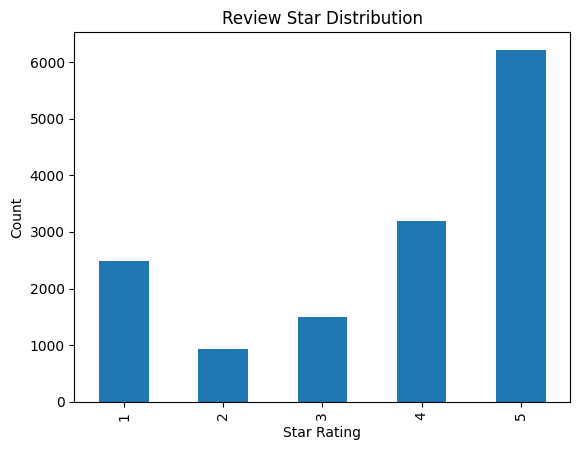

In [21]:
import matplotlib.pyplot as plt

df["ReviewStar"].value_counts().sort_index().plot(kind="bar")

plt.title("Review Star Distribution")
plt.xlabel("Star Rating")
plt.ylabel("Count")
plt.show()

In [22]:
df["Satisfied"].value_counts(normalize=True)*100

,proportion
Satisfied,
1,65.578573
0,34.421427


In [23]:
df[["ReviewStar","Price","MRP","DiscountRate","ReviewLength"]].describe()

,ReviewStar,Price,MRP,DiscountRate,ReviewLength
count,14337.000000,14337.000000,14337.000000,14337.000000,14337.000000
mean,3.675874,3369.084816,4519.253470,31.267600,126.584362
std,1.503409,2329.266550,2223.793412,19.679364,154.807798
min,1.000000,749.000000,2000.000000,11.465250,1.000000
25%,3.000000,1399.000000,2990.000000,13.230975,36.000000
50%,4.000000,2000.000000,2990.000000,30.194376,88.000000
75%,5.000000,6499.000000,7490.000000,53.210702,160.000000
max,5.000000,6499.000000,7490.000000,72.518130,5046.000000


In [24]:
# Ürün bazında yorum sayısı ve ortalama puan
product_summary = df.groupby("Product").agg(
    review_count=("ReviewStar", "count"),
    avg_rating=("ReviewStar", "mean"),
    price=("Price", "first"),
    mrp=("MRP", "first")
).sort_values(by="review_count", ascending=False)

product_summary

,review_count,avg_rating,price,mrp
Product,,,,
Sennheiser CX 6.0BT,5000,4.048200,6499,7490
boAt Rockerz 255,5000,3.628600,1399,2990
JBL T110BT,1922,3.047347,2000,2259
JBL T205BT,1411,3.367116,1999,2999
PTron Intunes,254,3.889764,749,2000
Skullcandy S2PGHW-174,239,3.230126,3699,5299
Samsung EO-BG950CBEIN,224,3.566964,3190,3799
Flybot Wave,182,3.851648,1099,3999
Flybot Boom,82,4.243902,1099,3999


Şikayet kategorisi dağılımı

In [25]:
df["ComplaintCategory"] = df["ReviewBody"].apply(
    complaint_category
)

df["ComplaintCategory"].value_counts()

,count
ComplaintCategory,
Sound,5094
Other,3459
Battery,2189
Comfort,1287
Connectivity,1065
Durability,508
Price,471
Mic,264


Kategori bazlı memnuniyet

In [26]:
category_satisfaction = pd.crosstab(
    df["ComplaintCategory"],
    df["Satisfied"],
    normalize="index"
) * 100

category_satisfaction.columns = [
    "NotSatisfied%",
    "Satisfied%"
]

category_satisfaction.sort_values(
    by="NotSatisfied%",
    ascending=False
)

,NotSatisfied%,Satisfied%
ComplaintCategory,,
Mic,60.227273,39.772727
Connectivity,49.295775,50.704225
Comfort,48.562549,51.437451
Durability,41.141732,58.858268
Battery,34.901782,65.098218
Other,31.425267,68.574733
Sound,28.661170,71.338830
Price,22.505308,77.494692


In [27]:
pd.crosstab(
    df["ComplaintCategory"],
    df["Satisfied"],
    normalize="index"
) * 100

Satisfied,0,1
ComplaintCategory,,
Battery,34.901782,65.098218
Comfort,48.562549,51.437451
Connectivity,49.295775,50.704225
Durability,41.141732,58.858268
Mic,60.227273,39.772727
Other,31.425267,68.574733
Price,22.505308,77.494692
Sound,28.661170,71.338830


# 7. Korelasyon Analizi

Bu bölümde müşteri memnuniyeti, yorum puanı, duygu analizi skoru, indirim oranı ve yorum uzunluğu gibi değişkenler arasındaki ilişkiler incelenmiştir. Korelasyon matrisi yardımıyla değişkenler arasındaki doğrusal ilişkiler değerlendirilmiştir.

In [28]:
df[[
    "ReviewStar",
    "DiscountRate",
    "ReviewLength",
    "SentimentScore",
    "Satisfied"
]].corr(numeric_only=True)

,ReviewStar,DiscountRate,ReviewLength,SentimentScore,Satisfied
ReviewStar,1.000000,-0.023606,-0.058201,0.650031,0.904307
DiscountRate,-0.023606,1.000000,0.061561,-0.017385,-0.019312
ReviewLength,-0.058201,0.061561,1.000000,0.096318,-0.060729
SentimentScore,0.650031,-0.017385,0.096318,1.000000,0.621805
Satisfied,0.904307,-0.019312,-0.060729,0.621805,1.000000


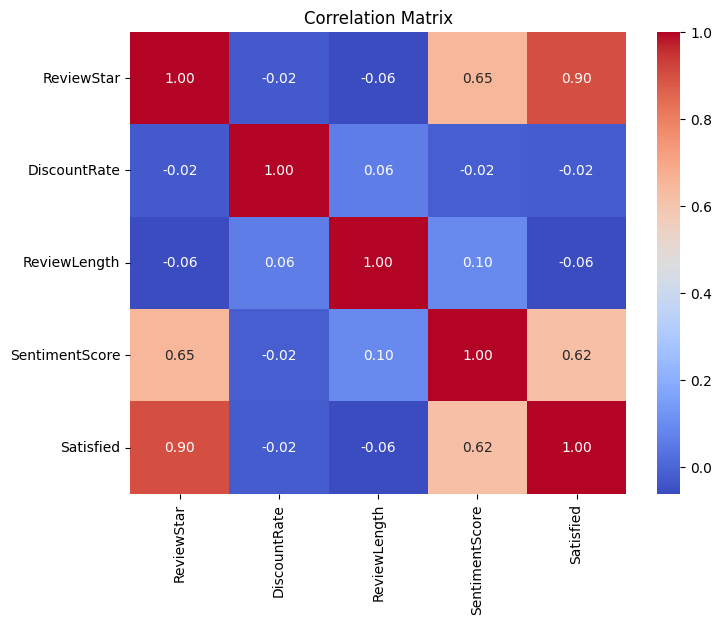

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df[
    ["ReviewStar","DiscountRate","ReviewLength",
     "SentimentScore","Satisfied"]
].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

# 8. Makine Öğrenmesi Modeli

Bu bölümde müşteri memnuniyetini tahmin etmek amacıyla Random Forest sınıflandırma modeli kurulmuştur. Hedef değişken olarak 4 ve 5 yıldız veren kullanıcılar memnun, 1-3 yıldız veren kullanıcılar memnun değil olarak etiketlenmiştir.

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Modelde kullanacağımız değişkenler
features = [
    "Price",
    "MRP",
    "DiscountRate",
    "ReviewLength",
    "SentimentScore",
    "ComplaintCategory",
    "Product"
]

X = df[features]
y = df["Satisfied"]

# Eğitim-test ayrımı
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

categorical_features = ["ComplaintCategory", "Product"]
numeric_features = ["Price", "MRP", "DiscountRate", "ReviewLength", "SentimentScore"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7981171548117155
[[ 685  302]
 [ 277 1604]]
              precision    recall  f1-score   support

           0       0.71      0.69      0.70       987
           1       0.84      0.85      0.85      1881

    accuracy                           0.80      2868
   macro avg       0.78      0.77      0.78      2868
weighted avg       0.80      0.80      0.80      2868



# 9. Açıklanabilir Yapay Zeka (SHAP)

Bu bölümde Random Forest modelinin tahmin kararlarını açıklamak amacıyla SHAP yöntemi kullanılmıştır. SHAP analizi sayesinde müşteri memnuniyetini etkileyen değişkenlerin model üzerindeki etkisi görselleştirilmiştir.

In [31]:
!pip install shap

In [32]:
# Test verisini modele girmeden önce dönüştürme
X_test_transformed = model.named_steps["preprocessor"].transform(X_test)

# Özellik isimlerini alma
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

# Random Forest modelini alma
rf_model = model.named_steps["classifier"]

# SHAP explainer
explainer = shap.TreeExplainer(rf_model)

# İşlem uzun sürmesin diye test verisinden örnek alıyoruz
X_sample = X_test_transformed[:500]

shap_values = explainer.shap_values(X_sample)

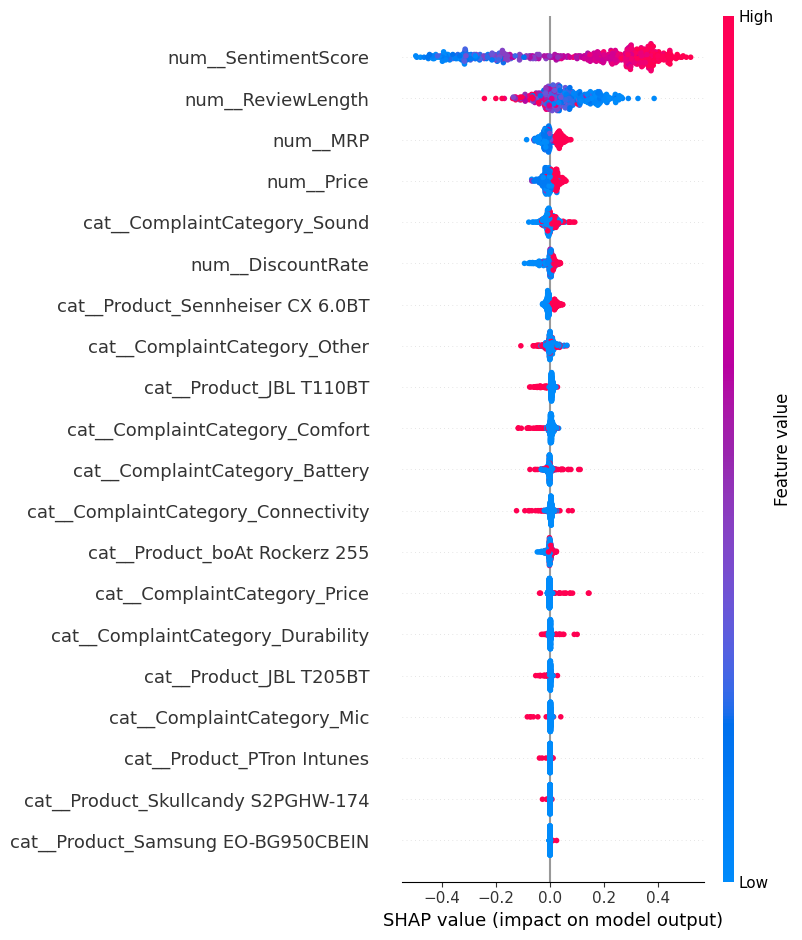

In [33]:
# SHAP çıktısı 3 boyutlu geldiyse pozitif sınıfı al
if len(shap_values.shape) == 3:
    shap_values_class1 = shap_values[:, :, 1]
else:
    shap_values_class1 = shap_values[1]

shap.summary_plot(
    shap_values_class1,
    X_sample,
    feature_names=feature_names
)

# 10. Finansal Simülasyon

Bu bölümde ürün geliştirme yatırımlarının finansal etkisi değerlendirilmiştir. Mikrofon probleminin giderilmesi durumunda satış dönüşüm oranındaki artış varsayılmış ve elde edilebilecek ek kârlılık hesaplanmıştır.

In [34]:
# Finansal Simülasyon: Mikrofon iyileştirme senaryosu

total_reviews = len(df)

# Mic kategorisindeki yorumlar
mic_df = df[df["ComplaintCategory"] == "Mic"]

mic_reviews = len(mic_df)
mic_not_satisfied_rate = 1 - mic_df["Satisfied"].mean()

# Varsayımlar
monthly_visitors = 100000          # aylık ürün sayfası ziyaretçisi
current_conversion_rate = 0.03     # mevcut satın alma dönüşüm oranı
improved_conversion_rate = 0.037   # iyileştirme sonrası tahmini dönüşüm
average_price = df["Price"].mean()
profit_margin = 0.25               # ürün başı kâr marjı
development_cost = 100000          # mikrofon iyileştirme maliyeti

# Mevcut ve iyileştirme sonrası satış
current_sales = monthly_visitors * current_conversion_rate
improved_sales = monthly_visitors * improved_conversion_rate
additional_sales = improved_sales - current_sales

# Finansal etki
profit_per_unit = average_price * profit_margin
additional_profit = additional_sales * profit_per_unit
net_profit = additional_profit - development_cost
roi = (net_profit / development_cost) * 100

simulation_results = {
    "Mic Reviews": mic_reviews,
    "Mic Not Satisfied Rate": mic_not_satisfied_rate,
    "Average Price": average_price,
    "Current Monthly Sales": current_sales,
    "Improved Monthly Sales": improved_sales,
    "Additional Sales": additional_sales,
    "Profit Per Unit": profit_per_unit,
    "Additional Profit": additional_profit,
    "Development Cost": development_cost,
    "Net Profit": net_profit,
    "ROI (%)": roi
}

simulation_results

{'Mic Reviews': 264,
 'Mic Not Satisfied Rate': np.float64(0.6022727272727273),
 'Average Price': np.float64(3369.084815512311),
 'Current Monthly Sales': 3000.0,
 'Improved Monthly Sales': 3700.0,
 'Additional Sales': 700.0,
 'Profit Per Unit': np.float64(842.2712038780777),
 'Additional Profit': np.float64(589589.8427146544),
 'Development Cost': 100000,
 'Net Profit': np.float64(489589.8427146544),
 'ROI (%)': np.float64(489.58984271465437)}

# 11. Sonuç

Bu çalışmada Amazon kablosuz kulaklık ürünlerine ait kullanıcı yorumları ve ürün bilgileri birleştirilerek müşteri memnuniyetini etkileyen faktörler analiz edilmiştir.

Keşifsel veri analizi sonucunda yıldız puanı, yorum uzunluğu, duygu analizi skoru ve şikâyet kategorilerinin müşteri memnuniyeti ile ilişkili olduğu görülmüştür.

Random Forest modeli kullanılarak müşteri memnuniyeti tahmin edilmiş ve model kararları SHAP yöntemi ile açıklanmıştır. SHAP analizi, ürün memnuniyetini etkileyen en önemli değişkenleri ortaya koymuştur.

Finansal simülasyon sonucunda mikrofon problemlerinin giderilmesinin satış dönüşüm oranını artırabileceği ve yaklaşık %489 ROI sağlayabileceği görülmüştür.

Elde edilen sonuçlar ürün geliştirme yatırımlarının veri temelli şekilde önceliklendirilmesine katkı sağlayabilecek niteliktedir.